In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [5]:
files = {
    ("Flute", "from_scratch"): "evaluation/results/mmd_flute_from_scratch.csv",
    ("Flute", "finetuned"): "evaluation/results/mmd_flute_finetuned_from_30k_for_30k.csv",
    ("Trumpet", "from_scratch"): "evaluation/results/mmd_trumpet_from_scratch.csv",
    ("Trumpet", "finetuned"): "evaluation/results/mmd_trumpet_finetuned_from_30k_for_30k.csv",
    ("Violin", "from_scratch"): "evaluation/results/mmd_violin_from_scratch.csv",
    ("Violin", "finetuned"): "evaluation/results/mmd_violin_finetuned_from_30k_for_30k.csv",
}

In [72]:
DATA_DIR = "../"
frames = []
for (instrument, model), fname in files.items():
    df = pd.read_csv(f"{DATA_DIR}/{fname}")
    df["instrument"] = instrument
    df["model"] = model
    frames.append(df)

data_all = pd.concat(frames, ignore_index=True)
data_all.head()

,resynth_path,model,category,method,grouping,pair,instrument,alpha,distance
0,../data/URMP/Dataset/rearranged/test_fl,from_scratch,NaN,NaN,NaN,NaN,Flute,NaN,0.040360
1,../data/URMP/Dataset/rearranged/test_tpt,from_scratch,NaN,NaN,NaN,NaN,Flute,NaN,0.298856
2,../data/URMP/Dataset/rearranged/test_vn,from_scratch,NaN,NaN,NaN,NaN,Flute,NaN,0.165266
3,./results_reordered/from_scratch/resynthesis/fl,from_scratch,resynthesis,NaN,NaN,NaN,Flute,NaN,0.147401
4,./results_reordered/from_scratch/output/fl_tpt...,from_scratch,output,output,NaN,fl_tpt,Flute,alpha_0,0.131088


In [50]:
def reformat_alpha(df):
    df["alpha"] = (
        df["alpha"]
        .astype(str)
        .str.replace("alpha_", "", regex=False)
        .astype(float)
    )
    return df

In [73]:
data_all = reformat_alpha(data_all)

In [ ]:
model_colors = {"from_scratch": "tab:blue", "finetuned": "tab:orange"}
method_styles = {"output": "-", "weights": "--"}

def plot_mmd_instrument(instrument, df):
    pairs = df[df["instrument"] == instrument]["pair"].unique()
    pairs = [p for p in pairs if pd.notna(p)]
    for pair in pairs:
        plt.figure()
        for model in ["from_scratch", "finetuned"]:
            for method in ["output", "weights"]:
                df_subset = df[
                    (df["instrument"] == instrument)
                    & (df["method"] == method)
                    & (df["model"] == model)
                    & (df["pair"] == pair)
                ].sort_values("alpha")

                if df_subset.empty:
                    continue

                plt.plot(
                    df_subset["alpha"],
                    df_subset["distance"],
                    label=f"{model} - {method} - {pair}",
                    color=model_colors[model],
                    linestyle=method_styles[method],
                )
        plt.xlabel(r"$\alpha$")
        plt.ylabel("MMD")
        plt.legend()

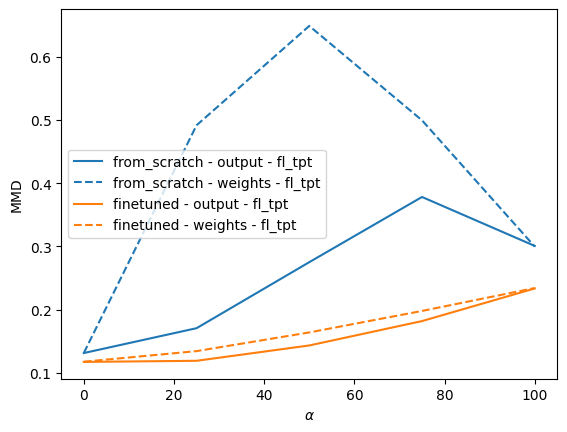

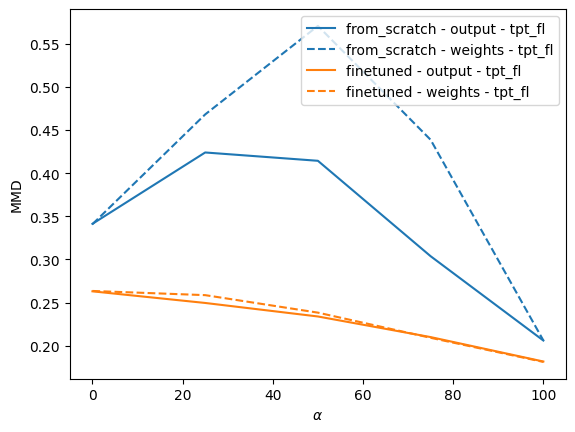

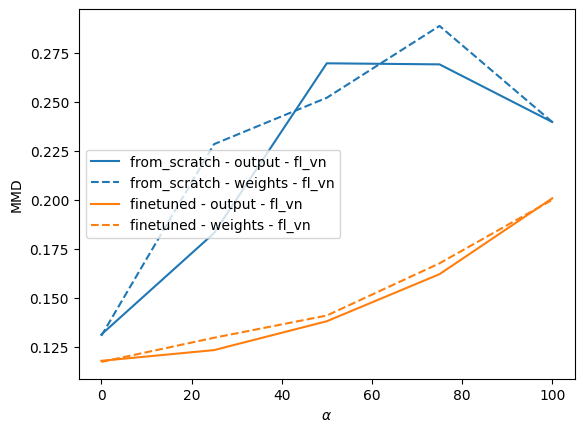

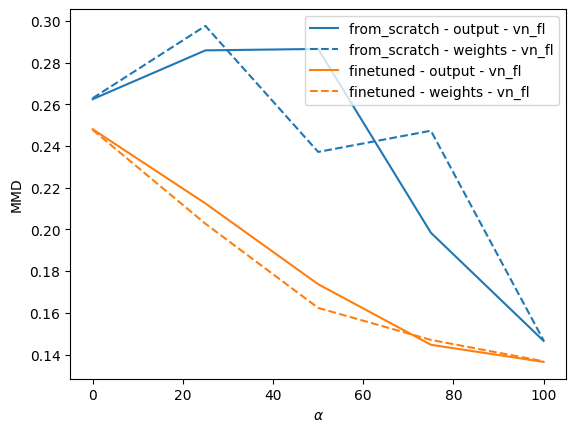

In [112]:
plot_mmd_instrument("Flute", data_all)

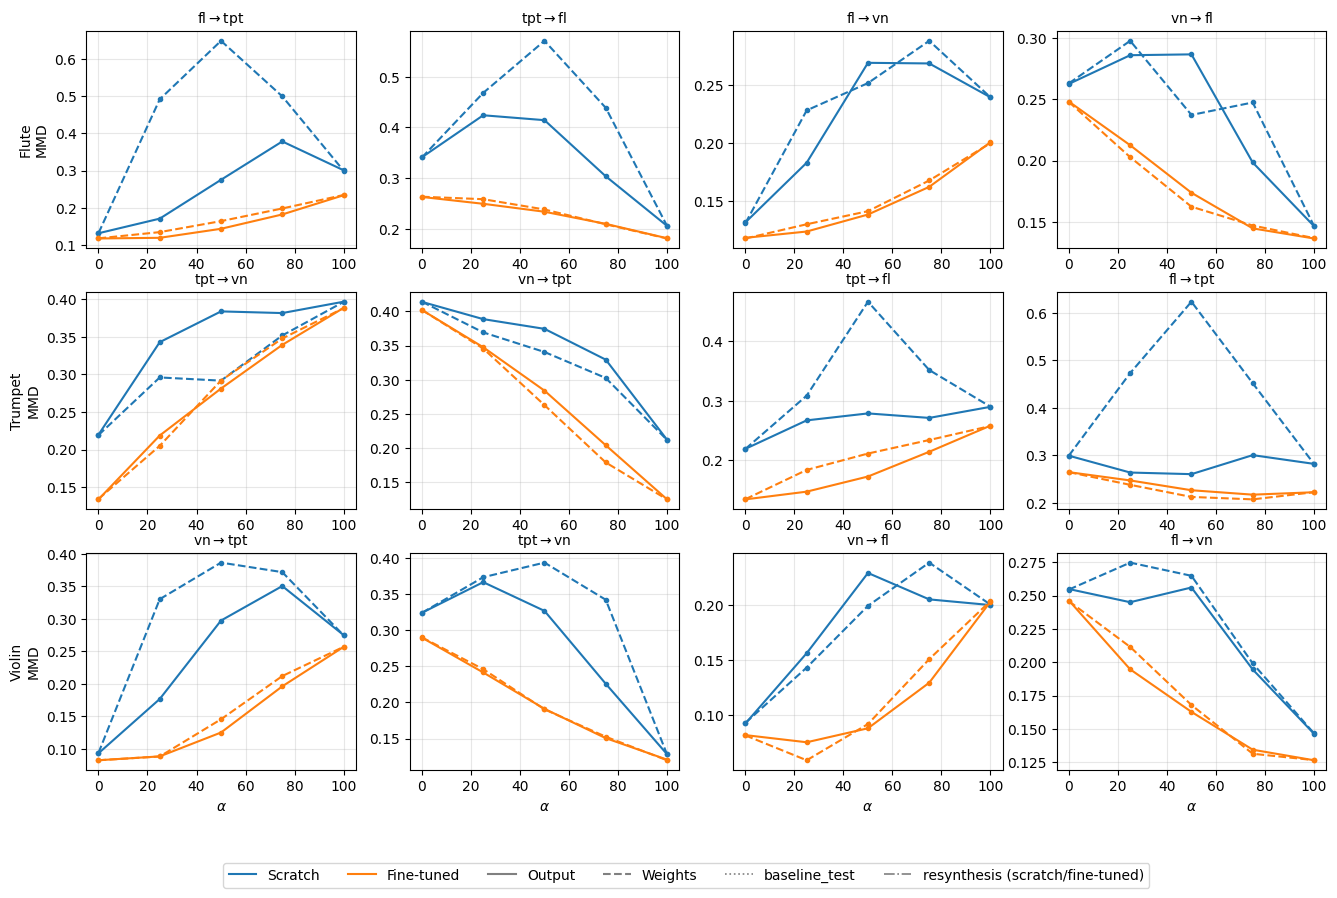

In [121]:
def plot_subset(df, instrument, pair, method, model, ax):
    df_subset = df[
        (df["instrument"] == instrument)
        & (df["pair"] == pair)
        & (df["method"] == method)
        & (df["model"] == model)
    ].sort_values("alpha")

    ax.plot(
        df_subset["alpha"],
        df_subset["distance"],
        marker="o",
        markersize=3,
        linestyle=method_styles[method],
        color=model_colors[model],
    )

def plot_reference(df, instrument, model, ax):
    values = df.loc[
        (df["instrument"] == instrument) & (df["pair"] == "resynthesis"),
        "distance",
    ]

    if not values.empty:
        ax.axhline(
            y=values.iloc[0],
            linestyle="-.",
            linewidth=1.2,
            color=model_colors[model],
        )


def plot_baseline(df, instrument, ax):
    baseline_values = df.loc[
        (df["instrument"] == instrument) & (df["pair"] == "baseline_test"),
        "distance",
    ]

    if not baseline_values.empty:
        ax.axhline(
            y=baseline_values.iloc[0],
            linestyle=":",
            linewidth=1.2,
            color="gray",
        )


model_colors = {"from_scratch": "tab:blue", "finetuned": "tab:orange"}
method_styles = {"output": "-", "weights": "--"}

instruments = data_all["instrument"].unique()
pairs_by_ref = {
    instrument: data_all[data_all["instrument"] == instrument]["pair"].dropna().unique()
    for instrument in instruments
}
n_cols = max(len(pairs) for pairs in pairs_by_ref.values())

fig, axes = plt.subplots(len(instruments), n_cols, figsize=(4 * n_cols, 3.2 * len(instruments)))

for i, instrument in enumerate(instruments):
    pairs_for_instrument = pairs_by_ref[instrument]
    for j in range(n_cols):
        ax = axes[i, j]
        if j >= len(pairs_for_instrument):
            ax.axis("off")
            continue

        pair = pairs_for_instrument[j]

        for model in ["from_scratch", "finetuned"]:
            for method in ["output", "weights"]:
                plot_subset(data_all, instrument, pair, method, model, ax)

        for model in ["from_scratch", "finetuned"]:
            plot_reference(data_all, instrument, model, ax)

        plot_baseline(data_all, instrument, ax)

        ax.set_title(str(pair).replace("_", r"$\to$"), fontsize=10)
        ax.grid(alpha=0.3)
        if i == len(instruments) - 1:
            ax.set_xlabel(r"$\alpha$")
        if j == 0:
            ax.set_ylabel(f"{instrument}\nMMD")

legend_handles = [
    Line2D([0], [0], color="tab:blue", label="Scratch"),
    Line2D([0], [0], color="tab:orange", label="Fine-tuned"),
    Line2D([0], [0], color="gray", linestyle="-", label="Output"),
    Line2D([0], [0], color="gray", linestyle="--", label="Weights"),
    Line2D([0], [0], color="gray", linestyle=":", linewidth=1.2, label="baseline_test"),
    Line2D([0], [0], color="gray", linestyle="-.", linewidth=1.2, label="resynthesis (scratch/fine-tuned)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.02))